# HW 6 Record Linkage

Questo notebook implementa le prime fasi fondamentali del progetto di integrazione dati automotive:
- **Punto 4.A**: Generazione della Ground Truth mediante l'attributo VIN e pulizia dei dati rumorosi.
- **Punto 4.B**: Rimozione completa dell'attributo VIN dai dataset e dalla Ground Truth per evitare data leakage.
- **Punto 4.C**: Partizionamento della Ground Truth e dei dataset in split disgiunti (Train 60%, Validation 20%, Test 20%).
- **Punto 4.D**: Definizione delle strategie di blocking **B1** (esatto su `make`) e **B2** (Sorted Neighbourhood su `year`).
- **Punto 4.E**: Implementazione e valutazione delle regole di Record Linkage (Rule-based con matching 1-a-1 e Supervised ML con Logistic Regression).
- **Punto 4.H**: Misurazione omogenea dei tempi di inferenza disaggregati ($T_{\text{blocking}}$, $T_{\text{matching}}$, $T_{\text{inferenza}}$).


## Configurazione Ambiente e Dipendenze


In [ ]:
%pip install -q "recordlinkage==0.16" loguru

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 926.9/926.9 kB 67.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 360.4/360.4 kB 37.3 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import sys
import time
import random
from pathlib import Path

import numpy as np
import pandas as pd
import recordlinkage
from recordlinkage.classifiers import LogisticRegressionClassifier
from loguru import logger

os.environ['TZ'] = 'Europe/Rome'
time.tzset()

logger.remove()
logger.add(
    sys.stdout,
    colorize=True,
    format="<green>{time:YYYY-MM-DD HH:mm:ss}</green> | <level>{level: <8}</level> | <cyan>{message}</cyan>"
)

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

ARTIFACT_DIR = Path("/content/drive/MyDrive/data")
if not ARTIFACT_DIR.exists() and Path("/content/drive/MyDrive/ing_dati/data").exists():
    ARTIFACT_DIR = Path("/content/drive/MyDrive/ing_dati/data")

logger.info(f"Directory artifact di riferimento: {ARTIFACT_DIR}")

2026-09-13 10:06:17 | INFO     | Directory artifact di riferimento: /content/drive/MyDrive/data


## Caricamento dei Dataset e Allineamento Tipi


In [ ]:
DATA_DIR = Path("/content/drive/MyDrive/data")
if not (DATA_DIR / "vehicles_final.csv").exists() and Path("/content/drive/MyDrive/ing_dati/data").exists():
    DATA_DIR = Path("/content/drive/MyDrive/ing_dati/data")

vehicles = pd.read_csv(DATA_DIR / "vehicles_final.csv")
used_cars = pd.read_csv(DATA_DIR / "used_cars_final.csv")


In [ ]:
#ripristino del tipo corretto di year
vehicles["year"] = pd.to_numeric(vehicles["year"], errors="coerce").astype("Int64")
used_cars["year"] = pd.to_numeric(used_cars["year"], errors="coerce").astype("Int64")

logger.info(f"Dataset caricati da: {DATA_DIR}")
logger.info(f"Vehicles: {len(vehicles):,} record | Used Cars: {len(used_cars):,} record")

2026-09-13 10:06:21 | INFO     | Dataset caricati da: /content/drive/MyDrive/data
2026-09-13 10:06:21 | INFO     | Vehicles: 3,947 record | Used Cars: 3,947 record


## 4.A Generazione e Pulizia della Ground Truth (tramite VIN)


In [ ]:
vehicles_schema = vehicles.reset_index(drop=True)
used_cars_schema = used_cars.reset_index(drop=True)

vehicles_schema["orig_cl_id"] = vehicles_schema.index
used_cars_schema["orig_uc_id"] = used_cars_schema.index

logger.info(f"Vehicles indicizzato: {len(vehicles_schema):,} record")
logger.info(f"Used Cars indicizzato: {len(used_cars_schema):,} record")


2026-09-13 10:06:21 | INFO     | Vehicles indicizzato: 3,947 record
2026-09-13 10:06:21 | INFO     | Used Cars indicizzato: 3,947 record


In [ ]:
ground_truth = (
    vehicles_schema[["orig_cl_id", "vin"]]
    .merge(
        used_cars_schema[["orig_uc_id", "vin"]],
        on="vin",
        how="inner"
    )
)

logger.info(f"Coppie trovate nella Ground Truth tramite VIN: {len(ground_truth):,}")
display(ground_truth.head())

2026-09-13 10:06:21 | INFO     | Coppie trovate nella Ground Truth tramite VIN: 3,947


,orig_cl_id,vin,orig_uc_id
0,0,3C6JR6DT3KG560649,1654
1,1,1FTEW1CP2KKC65268,1779
2,2,KL4MMGSL4LB128069,294
3,3,5J8YD4H39LL041518,641
4,4,1FTEW1EP0JFD83808,1524


In [ ]:
ground_truth = ground_truth[
    ["orig_cl_id", "orig_uc_id"]
].copy()

display(ground_truth.head())

,orig_cl_id,orig_uc_id
0,0,1654
1,1,1779
2,2,294
3,3,641
4,4,1524


## 4.C Partizionamento dei Dataset (Train 60% / Validation 20% / Test 20%)


In [ ]:
from sklearn.model_selection import train_test_split

train_gt, temp_gt = train_test_split(
    ground_truth,
    test_size=0.40,
    random_state=RANDOM_STATE
)

validation_gt, test_gt = train_test_split(
    temp_gt,
    test_size=0.50,
    random_state=RANDOM_STATE
)

logger.info(f"Ground Truth totale: {len(ground_truth):,} coppie")
logger.info(f"Training GT: {len(train_gt):,} (60%)")
logger.info(f"Validation GT: {len(validation_gt):,} (20%)")
logger.info(f"Test GT: {len(test_gt):,} (20%)")

2026-09-13 10:06:21 | INFO     | Ground Truth totale: 3,947 coppie
2026-09-13 10:06:21 | INFO     | Training GT: 2,368 (60%)
2026-09-13 10:06:21 | INFO     | Validation GT: 789 (20%)
2026-09-13 10:06:21 | INFO     | Test GT: 790 (20%)


## 4.B Rimozione dell'Attributo VIN dai Dataset e dalla Ground Truth


In [ ]:
vehicles_novin = vehicles_schema.drop(columns=["vin"]).copy()
used_cars_novin = used_cars_schema.drop(columns=["vin"]).copy()

logger.info(f"Controllo VIN in Vehicles: {'vin' in vehicles_novin.columns} (atteso: False)")
logger.info(f"Controllo VIN in Used Cars: {'vin' in used_cars_novin.columns} (atteso: False)")

display(vehicles_novin.head(3))
display(used_cars_novin.head(3))

2026-09-13 10:06:21 | INFO     | Controllo VIN in Vehicles: False (atteso: False)
2026-09-13 10:06:21 | INFO     | Controllo VIN in Used Cars: False (atteso: False)


,body_type,color,cylinders,description,drivetrain,fuel,latitude,listing_date,longitude,make,mileage,model,price,transmission,year,price_num,orig_cl_id
0,pickup,white,8.0,Carvana is the safer way to buy a car During t...,NaN,gas,32.59,2021-04-27 10:31:18-05:00,-85.48,ram,12302.0,1500 classic regular cab,25990,o,2019,25990,0
1,pickup,NaN,6.0,Carvana is the safer way to buy a car During t...,NaN,gas,32.59,2021-04-23 09:01:04-05:00,-85.48,ford,8663.0,f150 supercrew cab xl,37590,o,2019,37590,1
2,other,white,NaN,Carvana is the safer way to buy a car During t...,NaN,gas,32.59,2021-04-22 09:01:26-05:00,-85.48,buick,21.0,encore gx essence sport,28990,o,2020,28990,2


,body_type,color,cylinders,description,drivetrain,fuel,latitude,listing_date,longitude,make,mileage,model,price,transmission,year,price_num,orig_uc_id
0,sedan,white,6.0,"[!@@Additional Info@@!]ABS,4-Wheel Disc Brakes...",awd,gas,40.8168,2020-08-15T00:00:00.000000000Z,-73.4643,mercedes benz,50383.0,e class,17995.0,a,2014,17995.0,0
1,suv / crossover,black,4.0,"[!@@Additional Info@@!]4 Cylinder Engine,ABS,4...",awd,gas,40.8168,2020-07-26T00:00:00.000000000Z,-73.4643,bmw,22179.0,x1,22995.0,a,2017,22995.0,1
2,sedan,black,4.0,"[!@@Additional Info@@!]4 Cylinder Engine,ABS,4...",awd,gas,40.8168,2020-08-22T00:00:00.000000000Z,-73.4643,audi,78777.0,a4,19985.0,a,2017,19985.0,2


In [ ]:
def create_split_datasets(df_cl, df_uc, gt_split):
    cl_ids = gt_split["orig_cl_id"]
    uc_ids = gt_split["orig_uc_id"]

    cl_split = (
        df_cl[df_cl["orig_cl_id"].isin(cl_ids)]
        .copy()
        .set_index("orig_cl_id", drop=False)
    )

    uc_split = (
        df_uc[df_uc["orig_uc_id"].isin(uc_ids)]
        .copy()
        .set_index("orig_uc_id", drop=False)
    )

    return cl_split, uc_split

vehicles_train, used_cars_train = create_split_datasets(
    vehicles_novin,
    used_cars_novin,
    train_gt
)

vehicles_val, used_cars_val = create_split_datasets(
    vehicles_novin,
    used_cars_novin,
    validation_gt
)

vehicles_test, used_cars_test = create_split_datasets(
    vehicles_novin,
    used_cars_novin,
    test_gt
)

#convertiamo year a string su tutti gli split per garantire compatibilita con blocking e comparatori
for df in [vehicles_train, used_cars_train, vehicles_val, used_cars_val, vehicles_test, used_cars_test]:
    df["year"] = df["year"].astype("string")

logger.info(f"TRAIN: Vehicles={len(vehicles_train):,} | Used Cars={len(used_cars_train):,}")
logger.info(f"VALIDATION: Vehicles={len(vehicles_val):,} | Used Cars={len(used_cars_val):,}")
logger.info(f"TEST: Vehicles={len(vehicles_test):,} | Used Cars={len(used_cars_test):,}")

2026-09-13 10:06:21 | INFO     | TRAIN: Vehicles=2,368 | Used Cars=2,368
2026-09-13 10:06:21 | INFO     | VALIDATION: Vehicles=789 | Used Cars=789
2026-09-13 10:06:21 | INFO     | TEST: Vehicles=790 | Used Cars=790


## Generazione delle Coppie Etichettate con Negativi (Campionamento Bilanciato 1:5 per ML)


In [ ]:
def generate_labeled_pairs(gt_split, df_cl, df_uc, n_neg_per_pos=5, seed=42):
    """
    genera un DataFrame di coppie etichettate (1 positivo : n_neg_per_pos negativi).
    include negativi bilanciati per Make (per B1), per Year (per B2) e Random (cross-make/year)
    cosi che i modelli supervisionati (es. Logistic Regression) apprendano pesi positivi forti
    sia su Make che su Year, oltre che su Model, Mileage e Price.
    """
    rng = random.Random(seed)
    true_pairs = set(zip(ground_truth["orig_cl_id"], ground_truth["orig_uc_id"]))

    cl_ids = df_cl["orig_cl_id"].tolist()
    uc_ids = df_uc["orig_uc_id"].tolist()

    pairs_list = []
    seen_pairs = set()

    # 1. Positivi (label = 1)
    for _, row in gt_split.iterrows():
        cl_id = int(row["orig_cl_id"])
        uc_id = int(row["orig_uc_id"])
        pair = (cl_id, uc_id)

        pairs_list.append({
            "orig_cl_id": cl_id,
            "orig_uc_id": uc_id,
            "label": 1
        })
        seen_pairs.add(pair)

    num_pos = len(gt_split)
    target_neg = num_pos * n_neg_per_pos
    neg_count = 0

    #raggruppamenti per Make e per Year
    uc_by_make = df_uc.groupby("make")["orig_uc_id"].apply(list).to_dict()
    df_uc_temp = df_uc.copy()
    df_uc_temp["year_str"] = df_uc_temp["year"].astype(str)
    uc_by_year = df_uc_temp.groupby("year_str")["orig_uc_id"].apply(list).to_dict()

    cl_records = df_cl[["orig_cl_id", "make", "year"]].set_index("orig_cl_id").to_dict("index")

    max_attempts = target_neg * 50
    attempts = 0

    while neg_count < target_neg and attempts < max_attempts:
        attempts += 1
        cl_id = rng.choice(cl_ids)
        cl_info = cl_records.get(cl_id, {})
        cl_make = cl_info.get("make")
        cl_year = str(cl_info.get("year"))

        p = rng.random()
        if p < 0.35 and cl_make in uc_by_make and len(uc_by_make[cl_make]) > 1:
            # 35% Hard negatives per B1 (stessa marca, anno/modello diverso)
            uc_id = rng.choice(uc_by_make[cl_make])
        elif p < 0.70 and cl_year in uc_by_year and len(uc_by_year[cl_year]) > 1:
            # 35% Hard negatives per B2 (stesso anno, marca diversa)
            uc_id = rng.choice(uc_by_year[cl_year])
        else:
            # 30% Random negatives (marca diversa e anno diverso)
            uc_id = rng.choice(uc_ids)

        pair = (cl_id, uc_id)
        if pair in true_pairs or pair in seen_pairs:
            continue

        seen_pairs.add(pair)
        pairs_list.append({
            "orig_cl_id": cl_id,
            "orig_uc_id": uc_id,
            "label": 0
        })
        neg_count += 1

    df_pairs = pd.DataFrame(pairs_list)
    logger.info(f"Generati {len(df_pairs):,} esempi: {num_pos:,} positivi (1) e {neg_count:,} negativi (0)")
    return df_pairs

train_pairs_df = generate_labeled_pairs(train_gt, vehicles_train, used_cars_train, n_neg_per_pos=5, seed=RANDOM_STATE)
val_pairs_df   = generate_labeled_pairs(validation_gt, vehicles_val, used_cars_val, n_neg_per_pos=5, seed=RANDOM_STATE)
test_pairs_df  = generate_labeled_pairs(test_gt, vehicles_test, used_cars_test, n_neg_per_pos=5, seed=RANDOM_STATE)

2026-09-13 10:06:21 | INFO     | Generati 14,208 esempi: 2,368 positivi (1) e 11,840 negativi (0)
2026-09-13 10:06:21 | INFO     | Generati 4,734 esempi: 789 positivi (1) e 3,945 negativi (0)
2026-09-13 10:06:22 | INFO     | Generati 4,740 esempi: 790 positivi (1) e 3,950 negativi (0)


## 4.D Strategie di Blocking (B1: Make, B2: Year)

Definiamo le due strategie di blocking richieste dalla traccia d'esame per ridurre lo spazio cartesiano ($790 \times 790 = 624.100$ possibili coppie):
1. **B1**: Blocco esatto sull'attributo `make`.
2. **B2**: Sorted Neighbourhood sull'attributo `year` con ampiezza finestra $w=1$.


In [ ]:
def create_candidates(df1, df2, strategy):
    """
    genera le candidate pairs a partire dai DataFrame e misura il tempo di blocking.
    """
    start = time.perf_counter()
    indexer = recordlinkage.Index()
    if strategy == "B1":
        indexer.block(left_on="make", right_on="make")
    elif strategy == "B2":
        indexer.sortedneighbourhood(left_on="year", right_on="year", window=1)
    else:
        raise ValueError(f"Strategia non valida: {strategy}")
    candidates = indexer.index(df1, df2)
    blocking_time = time.perf_counter() - start
    return candidates, blocking_time

def blocking_metrics(candidates, gt_df, n_left, n_right):
    """
    calcola Blocking Recall e Reduction Ratio rispetto alla Ground Truth.
    """
    true_pairs = set(zip(gt_df["orig_cl_id"], gt_df["orig_uc_id"]))
    cand_set = set(candidates)
    captured = len(true_pairs.intersection(cand_set))
    recall = captured / len(true_pairs) if len(true_pairs) > 0 else 0.0
    cartesian = n_left * n_right
    rr = 1.0 - (len(candidates) / cartesian) if cartesian > 0 else 0.0
    return {
        "Candidate Pairs": len(candidates),
        "True matches captured": captured,
        "Blocking Recall": recall,
        "Reduction Ratio": rr
    }

#test preliminare delle due strategie su Test Set
candidates_b1, block_time_b1 = create_candidates(vehicles_test, used_cars_test, "B1")
candidates_b2, block_time_b2 = create_candidates(vehicles_test, used_cars_test, "B2")

logger.info(f"Numero record Vehicles test: {len(vehicles_test):,}")
logger.info(f"Numero record Used Cars test: {len(used_cars_test):,}")
logger.info(f"Possibili coppie cartesiane senza blocking: {len(vehicles_test) * len(used_cars_test):,}")
logger.info(f"Coppie candidate B1 (make): {len(candidates_b1):,} (tempo: {block_time_b1:.4f}s)")
logger.info(f"Coppie candidate B2 (year): {len(candidates_b2):,} (tempo: {block_time_b2:.4f}s)")

2026-09-13 10:06:22 | INFO     | Numero record Vehicles test: 790
2026-09-13 10:06:22 | INFO     | Numero record Used Cars test: 790
2026-09-13 10:06:22 | INFO     | Possibili coppie cartesiane senza blocking: 624,100
2026-09-13 10:06:22 | INFO     | Coppie candidate B1 (make): 43,456 (tempo: 0.0101s)
2026-09-13 10:06:22 | INFO     | Coppie candidate B2 (year): 49,757 (tempo: 0.0117s)


In [ ]:
stats_b1 = blocking_metrics(candidates_b1, test_gt, len(vehicles_test), len(used_cars_test))
stats_b2 = blocking_metrics(candidates_b2, test_gt, len(vehicles_test), len(used_cars_test))

logger.info("STATISTICHE BLOCKING TEST SET:")
logger.info(f"B1 (make) - Candidati: {stats_b1['Candidate Pairs']:,} | Match catturati: {stats_b1['True matches captured']}/{len(test_gt)} | Blocking Recall: {stats_b1['Blocking Recall']:.4f} | Reduction Ratio: {stats_b1['Reduction Ratio']:.4f}")
logger.info(f"B2 (year) - Candidati: {stats_b2['Candidate Pairs']:,} | Match catturati: {stats_b2['True matches captured']}/{len(test_gt)} | Blocking Recall: {stats_b2['Blocking Recall']:.4f} | Reduction Ratio: {stats_b2['Reduction Ratio']:.4f}")

2026-09-13 10:06:22 | INFO     | STATISTICHE BLOCKING TEST SET:
2026-09-13 10:06:22 | INFO     | B1 (make) - Candidati: 43,456 | Match catturati: 778/790 | Blocking Recall: 0.9848 | Reduction Ratio: 0.9304
2026-09-13 10:06:22 | INFO     | B2 (year) - Candidati: 49,757 | Match catturati: 787/790 | Blocking Recall: 0.9962 | Reduction Ratio: 0.9203


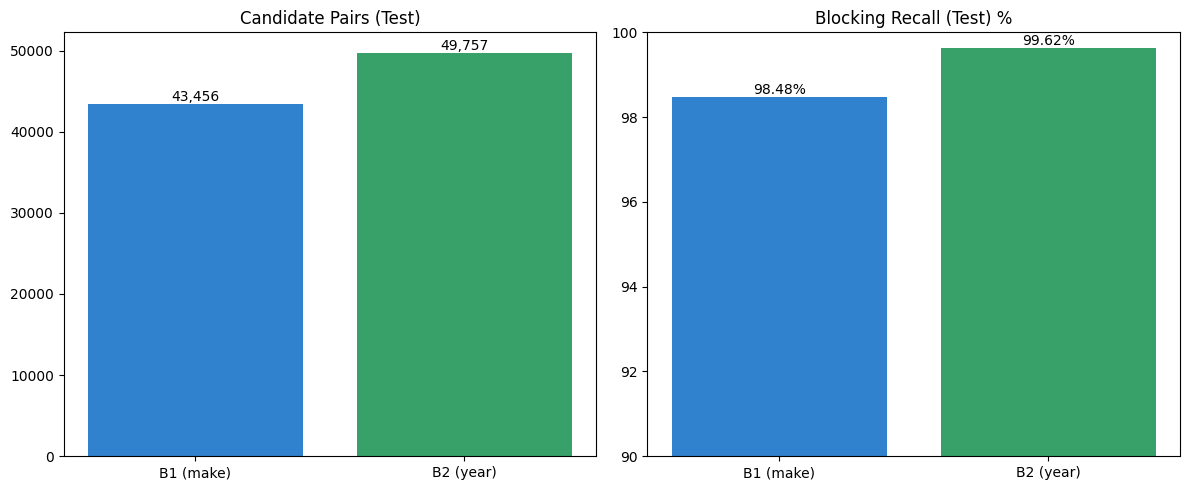

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

strategie = ["B1 (make)", "B2 (year)"]
candidate_pairs = [stats_b1["Candidate Pairs"], stats_b2["Candidate Pairs"]]
recall = [stats_b1["Blocking Recall"] * 100, stats_b2["Blocking Recall"] * 100]

axes[0].bar(strategie, candidate_pairs, color=["#3182ce", "#38a169"])
axes[0].set_title("Candidate Pairs (Test)")
for i, v in enumerate(candidate_pairs):
    axes[0].text(i, v, f"{v:,}", ha="center", va="bottom")

axes[1].bar(strategie, recall, color=["#3182ce", "#38a169"])
axes[1].set_ylim(90, 100)
axes[1].set_title("Blocking Recall (Test) %")
for i, v in enumerate(recall):
    axes[1].text(i, v, f"{v:.2f}%", ha="center", va="bottom")

plt.tight_layout()
plt.savefig("blocking_comparison.png", dpi=150)
plt.show()

## 4.E Regole di Record Linkage (Comparatori, Regole Euristiche e Risoluzione Conflitti)

Definiamo:
1. I **5 comparatori di attributi** con la libreria Python `recordlinkage`:
   - `make` (Jaro-Winkler, soglia 0.85)
   - `model` (Jaro-Winkler, soglia 0.75)
   - `year` (Levenshtein, soglia 0.90)
   - `mileage` (Gauss, tolleranza 500 miglia, scala 3000)
   - `price_num` (Gauss, tolleranza $500, scala $3500)
2. La **regola di classificazione euristica** con corroborazione multi-attributo e **risoluzione dei conflitti 1:1** basata su score decrescente.
3. La funzione di valutazione delle metriche (**Precision, Recall, F1**).


In [ ]:
def compare_records(candidates, df1, df2):
    compare = recordlinkage.Compare()

    #Marca (Jaro-Winkler, threshold 0.85)
    compare.string(
        "make",
        "make",
        method="jarowinkler",
        threshold=0.85,
        label="make"
    )

    #Modello (Jaro-Winkler, threshold 0.75)
    compare.string(
        "model",
        "model",
        method="jarowinkler",
        threshold=0.75,
        label="model"
    )

    #Anno (Levenshtein, threshold 0.9)
    compare.string(
        "year",
        "year",
        method="levenshtein",
        threshold=0.9,
        label="year"
    )

    #Chilometraggio (Gauss: tollera 500 miglia, scala 3000)
    compare.numeric(
        "mileage",
        "mileage",
        method="gauss",
        offset=500,
        scale=3000,
        missing_value=0.0,
        label="mileage"
    )

    #Prezzo (Gauss: tollera $500, scala $3500)
    compare.numeric(
        "price_num",
        "price_num",
        method="gauss",
        offset=500,
        scale=3500,
        missing_value=0.0,
        label="price"
    )

    features = compare.compute(
        candidates,
        df1,
        df2
    )

    return features

def classify_matches_rule(features, one_to_one=True):
    """
    regola di matching:
    1. marca e modello devono avere alta similarita (criterio "core"): richiesto sempre,
       indipendentemente da quale strategia di blocking (B1 o B2) ha generato il candidato.
    2. se one_to_one=True, risolve i conflitti tenendo solo il match a score piu alto per ogni auto.
    """
    #make e model: criterio core, sempre richiesto
    base_match = (
        (features["make"] >= 0.85) &
        (features["model"] >= 0.85)
    )

    #corroborazione: anno vicino, oppure prezzo/chilometraggio compatibili, oppure score complessivo alto
    corroborating = (
        (features["year"] >= 0.9) |
        (features["price"] >= 0.50) |
        (features["mileage"] >= 0.50) |
        (features.sum(axis=1) >= 3.8)
    )

    candidate_matches = features[base_match & corroborating].copy()

    #risoluzione dei conflitti 1:1 (elimina i falsi positivi da auto duplicate)
    if one_to_one and not candidate_matches.empty:
        candidate_matches["score_totale"] = candidate_matches.sum(axis=1)

        df_matches = candidate_matches.reset_index()

        #ordina per score decrescente e tiene il miglior match per ciascuna auto
        df_matches = df_matches.sort_values("score_totale", ascending=False)
        df_matches = df_matches.drop_duplicates(subset=["orig_cl_id"], keep="first")
        df_matches = df_matches.drop_duplicates(subset=["orig_uc_id"], keep="first")

        return list(zip(df_matches["orig_cl_id"], df_matches["orig_uc_id"]))

    return list(candidate_matches.index)

def evaluate_pairs(predicted_pairs, ground_truth):
    predicted = set(predicted_pairs)
    true_pairs = set(zip(ground_truth["orig_cl_id"], ground_truth["orig_uc_id"]))

    tp = len(predicted & true_pairs)
    fp = len(predicted - true_pairs)
    fn = len(true_pairs - predicted)

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) > 0 else 0.0

    return {
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    }

### 4.E.1 Record Linkage a Regole (Rule-based con Risoluzione Conflitti 1:1)

Eseguiamo l'**inferenza omogenea** per la pipeline a regole. Per garantire piena confrontabilità metodologica con Dedupe e Ditto (Punto 4.H), la pipeline parte dai DataFrame grezzi di test e misura in modo disaggregato:
- $T_{\text{blocking}}$: tempo per generare le candidate pairs
- $T_{\text{comparison}}$: tempo per estrarre le feature di similarità
- $T_{\text{selection}}$: tempo per applicare la regola decisionale e risolvere i vincoli 1:1
$$T_{\text{matching}} = T_{\text{comparison}} + T_{\text{selection}}$$
$$T_{\text{inferenza}} = T_{\text{blocking}} + T_{\text{matching}}$$


In [ ]:
def run_recordlinkage_rule_pipeline(strategy, df_cl, df_uc, gt):
    """
    inferenza omogenea per Record Linkage a regole:
    1. blocking: candidate generation da record grezzi a blocking_time
    2. comparison: calcolo feature con recordlinkage.Compare() a comparison_time
    3. selection: applicazione regole e matching 1-a-1 a selection_time
    """
    #Blocking
    candidates, blocking_time = create_candidates(df_cl, df_uc, strategy)
    block_stats = blocking_metrics(candidates, gt, len(df_cl), len(df_uc))

    #Feature Comparison - warm-up + multi-run (N=3), stesso protocollo usato per Ditto/Dedupe
    _ = compare_records(candidates, df_cl, df_uc)  # warm-up scartato dal cronometraggio

    N_RUNS = 3
    comparison_times = []
    features = None
    for _run_idx in range(N_RUNS):
        start_comp = time.perf_counter()
        curr_features = compare_records(candidates, df_cl, df_uc)
        comparison_times.append(time.perf_counter() - start_comp)
        if features is None:
            features = curr_features

    comparison_time = float(np.mean(comparison_times))
    comparison_time_std = float(np.std(comparison_times))

    #Decisione e Risoluzione Conflitti 1:1
    start_sel = time.perf_counter()
    matches = classify_matches_rule(features, one_to_one=True)
    selection_time = time.perf_counter() - start_sel

    matching_time = comparison_time + selection_time
    inference_time = blocking_time + matching_time

    metrics = evaluate_pairs(matches, gt)

    return {
        "strategy": strategy,
        "candidates": candidates,
        "features": features,
        "matches": matches,
        "metrics": metrics,
        "blocking": block_stats,
        "blocking_time": blocking_time,
        "comparison_time": comparison_time,
        "comparison_time_std": comparison_time_std,
        "selection_time": selection_time,
        "matching_time": matching_time,
        "inference_time": inference_time,
        "training_time": 0.0
    }

#inferenza omogenea B1 e B2 a Regole
rl_rule_test_b1 = run_recordlinkage_rule_pipeline("B1", vehicles_test, used_cars_test, test_gt)
rl_rule_test_b2 = run_recordlinkage_rule_pipeline("B2", vehicles_test, used_cars_test, test_gt)

#variabili di compatibilita
features_b1 = rl_rule_test_b1["features"]
features_b2 = rl_rule_test_b2["features"]
results_rule_b1 = {**rl_rule_test_b1["metrics"], "Train Time (s)": 0.0, "Inference Time (s)": rl_rule_test_b1["inference_time"]}
results_rule_b2 = {**rl_rule_test_b2["metrics"], "Train Time (s)": 0.0, "Inference Time (s)": rl_rule_test_b2["inference_time"]}

logger.info("RISULTATI INFERENZA OMOGENEA B1 - REGOLE:")
logger.info(f"P: {rl_rule_test_b1['metrics']['Precision']:.4f} | R: {rl_rule_test_b1['metrics']['Recall']:.4f} | F1: {rl_rule_test_b1['metrics']['F1']:.4f}")
logger.info(f"Dettaglio tempi: Blocking={rl_rule_test_b1['blocking_time']:.4f}s | Comparison={rl_rule_test_b1['comparison_time']:.4f}s | Selection={rl_rule_test_b1['selection_time']:.4f}s | Totale={rl_rule_test_b1['inference_time']:.4f}s")
logger.info("RISULTATI INFERENZA OMOGENEA B2 - REGOLE:")
logger.info(f"P: {rl_rule_test_b2['metrics']['Precision']:.4f} | R: {rl_rule_test_b2['metrics']['Recall']:.4f} | F1: {rl_rule_test_b2['metrics']['F1']:.4f}")
logger.info(f"Dettaglio tempi: Blocking={rl_rule_test_b2['blocking_time']:.4f}s | Comparison={rl_rule_test_b2['comparison_time']:.4f}s | Selection={rl_rule_test_b2['selection_time']:.4f}s | Totale={rl_rule_test_b2['inference_time']:.4f}s")

2026-09-13 10:06:26 | INFO     | RISULTATI INFERENZA OMOGENEA B1 - REGOLE:
2026-09-13 10:06:26 | INFO     | P: 0.9690 | R: 0.8696 | F1: 0.9166
2026-09-13 10:06:26 | INFO     | Dettaglio tempi: Blocking=0.0091s | Comparison=0.5634s | Selection=0.0142s | Totale=0.5866s
2026-09-13 10:06:26 | INFO     | RISULTATI INFERENZA OMOGENEA B2 - REGOLE:
2026-09-13 10:06:26 | INFO     | P: 0.9704 | R: 0.8709 | F1: 0.9179
2026-09-13 10:06:26 | INFO     | Dettaglio tempi: Blocking=0.0109s | Comparison=0.5075s | Selection=0.0121s | Totale=0.5304s


### 4.E.2 Record Linkage con Logistic Regression (Supervised ML su Dataset 1:5)

A scopo comparativo, addestriamo un modello supervisionato di **Logistic Regression** fornito dalla libreria `recordlinkage` sulle feature estratte dalle coppie di training (1 positivo : 5 negativi).


In [ ]:
#creiamo il MultiIndex per le coppie di training etichettate (1:5)
train_pairs_index = pd.MultiIndex.from_tuples(
    zip(train_pairs_df["orig_cl_id"], train_pairs_df["orig_uc_id"]),
    names=["orig_cl_id", "orig_uc_id"]
)

#calcoliamo le feature di comparazione sulle coppie del training set
train_features = compare_records(train_pairs_index, vehicles_train, used_cars_train)

#MultiIndex delle sole coppie positive (label == 1) presenti nei dati di training
train_matches_index = pd.MultiIndex.from_tuples(
    zip(train_gt["orig_cl_id"], train_gt["orig_uc_id"]),
    names=["orig_cl_id", "orig_uc_id"]
).intersection(train_features.index)

logger.info(f"Feature di training calcolate: {train_features.shape}")
logger.info(f"Match positivi di training: {len(train_matches_index):,}")

2026-09-13 10:06:27 | INFO     | Feature di training calcolate: (14208, 5)
2026-09-13 10:06:27 | INFO     | Match positivi di training: 2,368


In [ ]:
#addestramento della Logistic Regression sul dataset con 1 positivo e 5 negativi
log_reg = LogisticRegressionClassifier()

start_train_lr = time.perf_counter()
log_reg.fit(train_features, train_matches_index)
time_train_lr = time.perf_counter() - start_train_lr

logger.success(f"Modello Logistic Regression Addestrato in: {time_train_lr:.4f} s")
logger.info(f"Pesi appresi (coefficienti): {dict(zip(train_features.columns, np.round(log_reg.coefficients, 4)))}")
logger.info(f"Intercept: {log_reg.intercept:.4f}")

2026-09-13 10:06:27 | SUCCESS  | Modello Logistic Regression Addestrato in: 0.0247 s
2026-09-13 10:06:27 | INFO     | Pesi appresi (coefficienti): {'make': np.float64(2.4097), 'model': np.float64(3.8231), 'year': np.float64(4.856), 'mileage': np.float64(3.9), 'price': np.float64(1.5383)}
2026-09-13 10:06:27 | INFO     | Intercept: -11.1903


In [ ]:
def run_recordlinkage_lr_pipeline(strategy, df_cl, df_uc, gt, model, train_time=0.0):
    """
    inferenza omogenea per Record Linkage con Logistic Regression:
    1. blocking: candidate generation da record grezzi -> blocking_time
    2. comparison: calcolo feature con recordlinkage.Compare() -> comparison_time
    3. welection: predizione con modello log_reg -> selection_time
    """
    #Blocking
    candidates, blocking_time = create_candidates(df_cl, df_uc, strategy)
    block_stats = blocking_metrics(candidates, gt, len(df_cl), len(df_uc))

    #Feature Comparison - warm-up + multi-run (N=3), stesso protocollo usato per Ditto/Dedupe
    _ = compare_records(candidates, df_cl, df_uc)  # warm-up scartato dal cronometraggio

    N_RUNS = 3
    comparison_times = []
    features = None
    for _run_idx in range(N_RUNS):
        start_comp = time.perf_counter()
        curr_features = compare_records(candidates, df_cl, df_uc)
        comparison_times.append(time.perf_counter() - start_comp)
        if features is None:
            features = curr_features

    comparison_time = float(np.mean(comparison_times))
    comparison_time_std = float(np.std(comparison_times))

    #Predizione del classificatore
    start_sel = time.perf_counter()
    matches = list(model.predict(features))
    selection_time = time.perf_counter() - start_sel

    matching_time = comparison_time + selection_time
    inference_time = blocking_time + matching_time

    metrics = evaluate_pairs(matches, gt)

    return {
        "strategy": strategy,
        "candidates": candidates,
        "features": features,
        "matches": matches,
        "metrics": metrics,
        "blocking": block_stats,
        "blocking_time": blocking_time,
        "comparison_time": comparison_time,
        "comparison_time_std": comparison_time_std,
        "selection_time": selection_time,
        "matching_time": matching_time,
        "inference_time": inference_time,
        "training_time": train_time
    }

#inferenza omogenea B1 e B2 con Logistic Regression
rl_lr_test_b1 = run_recordlinkage_lr_pipeline("B1", vehicles_test, used_cars_test, test_gt, log_reg, train_time=time_train_lr)
rl_lr_test_b2 = run_recordlinkage_lr_pipeline("B2", vehicles_test, used_cars_test, test_gt, log_reg, train_time=time_train_lr)

results_lr_b1 = {**rl_lr_test_b1["metrics"], "Train Time (s)": time_train_lr, "Inference Time (s)": rl_lr_test_b1["inference_time"]}
results_lr_b2 = {**rl_lr_test_b2["metrics"], "Train Time (s)": time_train_lr, "Inference Time (s)": rl_lr_test_b2["inference_time"]}

logger.info("RISULTATI INFERENZA OMOGENEA B1 - LOGISTIC REGRESSION:")
logger.info(f"P: {rl_lr_test_b1['metrics']['Precision']:.4f} | R: {rl_lr_test_b1['metrics']['Recall']:.4f} | F1: {rl_lr_test_b1['metrics']['F1']:.4f}")
logger.info(f"Dettaglio tempi: Blocking={rl_lr_test_b1['blocking_time']:.4f}s | Comparison={rl_lr_test_b1['comparison_time']:.4f}s | Selection={rl_lr_test_b1['selection_time']:.4f}s | Totale={rl_lr_test_b1['inference_time']:.4f}s")
logger.info("RISULTATI INFERENZA OMOGENEA B2 - LOGISTIC REGRESSION:")
logger.info(f"P: {rl_lr_test_b2['metrics']['Precision']:.4f} | R: {rl_lr_test_b2['metrics']['Recall']:.4f} | F1: {rl_lr_test_b2['metrics']['F1']:.4f}")
logger.info(f"Dettaglio tempi: Blocking={rl_lr_test_b2['blocking_time']:.4f}s | Comparison={rl_lr_test_b2['comparison_time']:.4f}s | Selection={rl_lr_test_b2['selection_time']:.4f}s | Totale={rl_lr_test_b2['inference_time']:.4f}s")

2026-09-13 10:06:31 | INFO     | RISULTATI INFERENZA OMOGENEA B1 - LOGISTIC REGRESSION:
2026-09-13 10:06:31 | INFO     | P: 0.5992 | R: 0.9443 | F1: 0.7332
2026-09-13 10:06:31 | INFO     | Dettaglio tempi: Blocking=0.0100s | Comparison=0.4772s | Selection=0.0019s | Totale=0.4890s
2026-09-13 10:06:31 | INFO     | RISULTATI INFERENZA OMOGENEA B2 - LOGISTIC REGRESSION:
2026-09-13 10:06:31 | INFO     | P: 0.6006 | R: 0.9443 | F1: 0.7343
2026-09-13 10:06:31 | INFO     | Dettaglio tempi: Blocking=0.0108s | Comparison=0.5074s | Selection=0.0019s | Totale=0.5201s


## 4.H Tabella Comparativa Finale e Scomposizione Cronometrica Omogenea

Riassumiamo in una tabella comparativa master i risultati delle pipeline di Record Linkage sul Test Set, evidenziando accuratezza e scomposizione dei tempi (Training, Blocking, Matching, Inferenza totale).

In [ ]:
summary_rl_rows = [
    {
        "Pipeline": "B1 - RecordLinkage (Regole)",
        "Paradigma": "Rule-Based",
        "Blocking": "Make",
        "Set": "Test",
        **rl_rule_test_b1["metrics"],
        **rl_rule_test_b1["blocking"],
        "Train Time (s)": rl_rule_test_b1["training_time"],
        "Blocking Time (s)": rl_rule_test_b1["blocking_time"],
        "Model Time (s)": rl_rule_test_b1["comparison_time"],
        "Model Time Std (s)": rl_rule_test_b1["comparison_time_std"],
        "Selection Time (s)": rl_rule_test_b1["selection_time"],
        "Matching Time (s)": rl_rule_test_b1["matching_time"],
        "Inference Time (s)": rl_rule_test_b1["inference_time"],
    },
    {
        "Pipeline": "B2 - RecordLinkage (Regole)",
        "Paradigma": "Rule-Based",
        "Blocking": "Year",
        "Set": "Test",
        **rl_rule_test_b2["metrics"],
        **rl_rule_test_b2["blocking"],
        "Train Time (s)": rl_rule_test_b2["training_time"],
        "Blocking Time (s)": rl_rule_test_b2["blocking_time"],
        "Model Time (s)": rl_rule_test_b2["comparison_time"],
        "Model Time Std (s)": rl_rule_test_b2["comparison_time_std"],
        "Selection Time (s)": rl_rule_test_b2["selection_time"],
        "Matching Time (s)": rl_rule_test_b2["matching_time"],
        "Inference Time (s)": rl_rule_test_b2["inference_time"],
    },
    {
        "Pipeline": "B1 - RecordLinkage (Logistic Regression)",
        "Paradigma": "Supervised ML (RecordLinkage)",
        "Blocking": "Make",
        "Set": "Test",
        **rl_lr_test_b1["metrics"],
        **rl_lr_test_b1["blocking"],
        "Train Time (s)": rl_lr_test_b1["training_time"],
        "Blocking Time (s)": rl_lr_test_b1["blocking_time"],
        "Model Time (s)": rl_lr_test_b1["comparison_time"],
        "Model Time Std (s)": rl_lr_test_b1["comparison_time_std"],
        "Selection Time (s)": rl_lr_test_b1["selection_time"],
        "Matching Time (s)": rl_lr_test_b1["matching_time"],
        "Inference Time (s)": rl_lr_test_b1["inference_time"],
    },
    {
        "Pipeline": "B2 - RecordLinkage (Logistic Regression)",
        "Paradigma": "Supervised ML (RecordLinkage)",
        "Blocking": "Year",
        "Set": "Test",
        **rl_lr_test_b2["metrics"],
        **rl_lr_test_b2["blocking"],
        "Train Time (s)": rl_lr_test_b2["training_time"],
        "Blocking Time (s)": rl_lr_test_b2["blocking_time"],
        "Model Time (s)": rl_lr_test_b2["comparison_time"],
        "Model Time Std (s)": rl_lr_test_b2["comparison_time_std"],
        "Selection Time (s)": rl_lr_test_b2["selection_time"],
        "Matching Time (s)": rl_lr_test_b2["matching_time"],
        "Inference Time (s)": rl_lr_test_b2["inference_time"],
    },
]

df_summary_rl = pd.DataFrame(summary_rl_rows)

columns_rl = [
    "Pipeline",
    "Paradigma",
    "Blocking",
    "Candidate Pairs",
    "TP",
    "FP",
    "FN",
    "Precision",
    "Recall",
    "F1",
    "Blocking Recall",
    "Reduction Ratio",
    "Train Time (s)",
    "Blocking Time (s)",
    "Model Time (s)",
    "Model Time Std (s)",
    "Selection Time (s)",
    "Matching Time (s)",
    "Inference Time (s)",
]

display(
    df_summary_rl[columns_rl].style.format({
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}",
        "Blocking Recall": "{:.4f}",
        "Reduction Ratio": "{:.4f}",
        "Train Time (s)": "{:.4f}",
        "Blocking Time (s)": "{:.4f}",
        "Model Time (s)": "{:.4f}",
        "Model Time Std (s)": "{:.4f}",
        "Selection Time (s)": "{:.4f}",
        "Matching Time (s)": "{:.4f}",
        "Inference Time (s)": "{:.4f}",
    })
)

,Pipeline,Paradigma,Blocking,Candidate Pairs,TP,FP,FN,Precision,Recall,F1,Blocking Recall,Reduction Ratio,Train Time (s),Blocking Time (s),Model Time (s),Model Time Std (s),Selection Time (s),Matching Time (s),Inference Time (s)
0,B1 - RecordLinkage (Regole),Rule-Based,Make,43456,687,22,103,0.9690,0.8696,0.9166,0.9848,0.9304,0.0000,0.0091,0.5634,0.0269,0.0142,0.5775,0.5866
1,B2 - RecordLinkage (Regole),Rule-Based,Year,49757,688,21,102,0.9704,0.8709,0.9179,0.9962,0.9203,0.0000,0.0109,0.5075,0.0013,0.0121,0.5195,0.5304
2,B1 - RecordLinkage (Logistic Regression),Supervised ML (RecordLinkage),Make,43456,746,499,44,0.5992,0.9443,0.7332,0.9848,0.9304,0.0247,0.0100,0.4772,0.0020,0.0019,0.4790,0.4890
3,B2 - RecordLinkage (Logistic Regression),Supervised ML (RecordLinkage),Year,49757,746,496,44,0.6006,0.9443,0.7343,0.9962,0.9203,0.0247,0.0108,0.5074,0.0009,0.0019,0.5093,0.5201


## Salvataggio Artifact (Dataset, Ground Truth e Risultati Record Linkage)


In [ ]:
# Ground Truth e split
ground_truth.to_csv(f"{ARTIFACT_DIR}/ground_truth.csv", index=False)
train_gt.to_csv(f"{ARTIFACT_DIR}/train_gt.csv", index=False)
validation_gt.to_csv(f"{ARTIFACT_DIR}/validation_gt.csv", index=False)
test_gt.to_csv(f"{ARTIFACT_DIR}/test_gt.csv", index=False)

#coppie etichettate 1:5 (utilissime anche per Dedupe e Ditto)
train_pairs_df.to_csv(f"{ARTIFACT_DIR}/train_pairs_1_5.csv", index=False)
val_pairs_df.to_csv(f"{ARTIFACT_DIR}/val_pairs_1_5.csv", index=False)
test_pairs_df.to_csv(f"{ARTIFACT_DIR}/test_pairs_1_5.csv", index=False)

#dataset senza VIN
vehicles_novin.to_parquet(f"{ARTIFACT_DIR}/vehicles_novin.parquet", index=False)
used_cars_novin.to_parquet(f"{ARTIFACT_DIR}/used_cars_novin.parquet", index=False)

#split dataset separati
vehicles_train.to_parquet(f"{ARTIFACT_DIR}/vehicles_train.parquet", index=False)
used_cars_train.to_parquet(f"{ARTIFACT_DIR}/used_cars_train.parquet", index=False)
vehicles_val.to_parquet(f"{ARTIFACT_DIR}/vehicles_validation.parquet", index=False)
used_cars_val.to_parquet(f"{ARTIFACT_DIR}/used_cars_validation.parquet", index=False)
vehicles_test.to_parquet(f"{ARTIFACT_DIR}/vehicles_test.parquet", index=False)
used_cars_test.to_parquet(f"{ARTIFACT_DIR}/used_cars_test.parquet", index=False)

#salvataggio delle metriche di Record Linkage su Drive
df_summary_rl.to_csv(f"{ARTIFACT_DIR}/recordlinkage_results.csv", index=False)

logger.success(f"Tutti gli artifact salvati con successo in: {ARTIFACT_DIR}")
logger.info(f"- {ARTIFACT_DIR}/ground_truth.csv")
logger.info(f"- {ARTIFACT_DIR}/train_gt.csv")
logger.info(f"- {ARTIFACT_DIR}/validation_gt.csv")
logger.info(f"- {ARTIFACT_DIR}/test_gt.csv")
logger.info(f"- {ARTIFACT_DIR}/train_pairs_1_5.csv")
logger.info(f"- {ARTIFACT_DIR}/val_pairs_1_5.csv")
logger.info(f"- {ARTIFACT_DIR}/test_pairs_1_5.csv")
logger.info(f"- {ARTIFACT_DIR}/vehicles_novin.parquet")
logger.info(f"- {ARTIFACT_DIR}/used_cars_novin.parquet")
logger.info(f"- {ARTIFACT_DIR}/vehicles_train.parquet")
logger.info(f"- {ARTIFACT_DIR}/vehicles_validation.parquet")
logger.info(f"- {ARTIFACT_DIR}/vehicles_test.parquet")
logger.info(f"- {ARTIFACT_DIR}/recordlinkage_results.csv")

2026-09-13 10:06:51 | SUCCESS  | Tutti gli artifact salvati con successo in: /content/drive/MyDrive/data
2026-09-13 10:06:51 | INFO     | - /content/drive/MyDrive/data/ground_truth.csv
2026-09-13 10:06:51 | INFO     | - /content/drive/MyDrive/data/train_gt.csv
2026-09-13 10:06:51 | INFO     | - /content/drive/MyDrive/data/validation_gt.csv
2026-09-13 10:06:51 | INFO     | - /content/drive/MyDrive/data/test_gt.csv
2026-09-13 10:06:51 | INFO     | - /content/drive/MyDrive/data/train_pairs_1_5.csv
2026-09-13 10:06:51 | INFO     | - /content/drive/MyDrive/data/val_pairs_1_5.csv
2026-09-13 10:06:51 | INFO     | - /content/drive/MyDrive/data/test_pairs_1_5.csv
2026-09-13 10:06:51 | INFO     | - /content/drive/MyDrive/data/vehicles_novin.parquet
2026-09-13 10:06:51 | INFO     | - /content/drive/MyDrive/data/used_cars_novin.parquet
2026-09-13 10:06:51 | INFO     | - /content/drive/MyDrive/data/vehicles_train.parquet
2026-09-13 10:06:51 | INFO     | - /content/drive/MyDrive/data/vehicles_valida